# 03 · Unit-cell SMILES: especies desconectadas vs conectividad finita

Este notebook introduce una representación derivada de estructura y la compara, con los mismos folds y regresor, contra `composition_smiles`.

## Fundamento y alcance

[Quirós et al. (2018)](https://doi.org/10.1186/s13321-018-0279-6) produjeron SMILES a partir de CIF con Open Babel y curaron más de 160,000 estructuras del COD. El trabajo enfatiza que la conectividad no es inequívoca en sólidos iónicos, metálicos o extendidos: NaCl se representa como iones desconectados, los metales como átomos aislados y muchos cationes alcalinos/alcalinotérreos se dejan desconectados en redes extendidas. Su pipeline incluía intervención humana.

Aquí comparamos tres niveles automáticos:

1. **Reduced composition:** cinco especies desconectadas para `ABS3`.
2. **Unit cell disconnected:** las 20 especies reales de la celda, desconectadas. Este control mide el efecto de conservar la multiplicidad de la celda sin topología.
3. **Unit-cell graph:** `CrystalNN` infiere vecinos periódicos; después se proyectan las conexiones sobre los 20 sitios de la celda, se colapsan aristas paralelas, se omiten etiquetas de traslación y self-loops periódicos, y Open Babel serializa el grafo simple como SMILES canónico sin estereoquímica.

La tercera representación es una aproximación finita, no invertible y no es una reproducción del flujo curado del COD. Pierde geometría, multiplicidad de aristas y vectores periódicos; los enlaces de `CrystalNN` son heurísticos.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'results_no_meta.json').exists() and (candidate / 'transferability').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del repositorio')

REPO_ROOT = find_repo_root()
TRANSFERABILITY = REPO_ROOT / 'transferability'
SCRIPTS = TRANSFERABILITY / 'scripts'
ARTIFACTS = REPO_ROOT / 'artifacts'
TABLE = TRANSFERABILITY / 'data' / 'unit_cell_SMILES' / 'unit_cell_smiles.csv'
AUDIT = TABLE.with_suffix('.audit.json')
PYTHON = REPO_ROOT / '.venv' / 'bin' / 'python'
if not PYTHON.exists():
    PYTHON = Path(sys.executable)
print(f'Repositorio: {REPO_ROOT}')
print(f'Python para scripts: {PYTHON}')

Repositorio: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis
Python para scripts: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python


In [2]:
RUN_GENERATION = True
RUN_EMBEDDINGS = True
RUN_EVALUATION = True
DEVICE = 'auto'

def run_script(arguments, tail=1800):
    command = [str(PYTHON), *map(str, arguments)]
    print('$', ' '.join(command))
    completed = subprocess.run(
        command, cwd=REPO_ROOT, text=True, capture_output=True, check=True
    )
    combined = (completed.stdout + '\n' + completed.stderr).strip()
    if combined:
        print(combined[-tail:])

## 1. Generar y auditar las representaciones de celda

In [3]:
if RUN_GENERATION:
    run_script([SCRIPTS / 'prepare_unit_cell_smiles.py'], tail=3500)
table = pd.read_csv(TABLE)
audit = json.loads(AUDIT.read_text())

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/prepare_unit_cell_smiles.py


{
  "source": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/results_no_meta.json",
  "output": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv",
  "records": 480,
  "unique_crystal_graphs_computed": 240,
  "unique_formulas": 80,
  "unique_composition_smiles": 80,
  "unique_unit_cell_disconnected_smiles": 80,
  "unique_unit_cell_smiles": 240,
  "distinct_prototype_smiles_per_formula": {
    "3": 80
  },
  "formulas_with_all_three_prototypes_distinguished": 80,
  "disconnected_fallbacks": 0,
  "quotient_edges": {
    "min": 22,
    "median": 40.0,
    "max": 64
  },
  "methodological_warning": "This is a finite simple-graph approximation. CrystalNN bonds are heuristic; periodic translation labels, parallel edges, geometry, bond order, oxidation states, and periodic self-loops are not encoded. It is not an invertible representation of the crystal an

In [4]:
pd.DataFrame({
    'valor': [
        audit['records'],
        audit['unique_composition_smiles'],
        audit['unique_unit_cell_disconnected_smiles'],
        audit['unique_unit_cell_smiles'],
        audit['formulas_with_all_three_prototypes_distinguished'],
        audit['disconnected_fallbacks'],
    ]
}, index=[
    'registros', 'composition-SMILES únicos', 'unit-cell desconectados únicos',
    'unit-cell graph únicos', 'fórmulas con 3/3 prototipos distintos', 'fallbacks desconectados'
])

,valor
registros,480
composition-SMILES únicos,80
unit-cell desconectados únicos,80
unit-cell graph únicos,240
fórmulas con 3/3 prototipos distintos,80
fallbacks desconectados,0


## 2. Prueba indispensable: ¿distingue los tres prototipos?

In [5]:
static = table[table['calculation'] == 'gga-static'].copy()
distinct = static.groupby('canonical_reduced_formula').agg(
    composition_unique=('composition_smiles', 'nunique'),
    cell_disconnected_unique=('unit_cell_disconnected_smiles', 'nunique'),
    cell_graph_unique=('unit_cell_smiles', 'nunique'),
)
distinct.apply(pd.Series.value_counts).fillna(0).astype(int).sort_index()

,composition_unique,cell_disconnected_unique,cell_graph_unique
1,80,80,0
3,0,0,80


In [6]:
example_formula = static['canonical_reduced_formula'].iloc[0]
example = static.loc[
    static['canonical_reduced_formula'] == example_formula,
    ['prototype', 'quotient_edges', 'composition_smiles', 'unit_cell_disconnected_smiles', 'unit_cell_smiles'],
].sort_values('prototype')
with pd.option_context('display.max_colwidth', 140):
    display(example)

,prototype,quotient_edges,composition_smiles,unit_cell_disconnected_smiles,unit_cell_smiles
1,dist_perovskite,56,[Ba].[Ge].[S].[S].[S],[Ba].[Ba].[Ba].[Ba].[Ge].[Ge].[Ge].[Ge].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S],[Ge]123S45[Ge]67S81[Ba]19%10%11%12%13%14%15[S]%16%172[Ba]2%18%19%20%21%22%234[S]431[Ba]13%24%25%26%275%16[S]692[Ba]25698%174([S]7%10%181...
3,hexagonal,41,[Ba].[Ge].[S].[S].[S],[Ba].[Ba].[Ba].[Ba].[Ge].[Ge].[Ge].[Ge].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S],[S]12[Ge]34[S]5[Ba]6789%10S%114[Ba]4%125S53[Ba]3%13%14%152S24[Ge]41S63[Ba]152(S7%134)[S]%14[Ge]2([S]8%15)[S]9[Ge]%11([S]%102)[S]%121
5,needle,40,[Ba].[Ge].[S].[S].[S],[Ba].[Ba].[Ba].[Ba].[Ge].[Ge].[Ge].[Ge].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S].[S],[S]12[Ge]34[S]5[Ba]6781S13[Ba]39%102[S]7[Ge]27S83[Ge]38[S]9[Ba]9%11%12(S%134[Ba]45([S]6[Ge]1%13[S]%114)([S]39)S78%12)[S]%102


### Representación en el plano reconstruida desde `unit_cell_smiles`

Este dibujo se genera leyendo únicamente el SMILES. El layout 2D facilita inspeccionar especies y conexiones, pero no recupera coordenadas cristalográficas ni periodicidad.

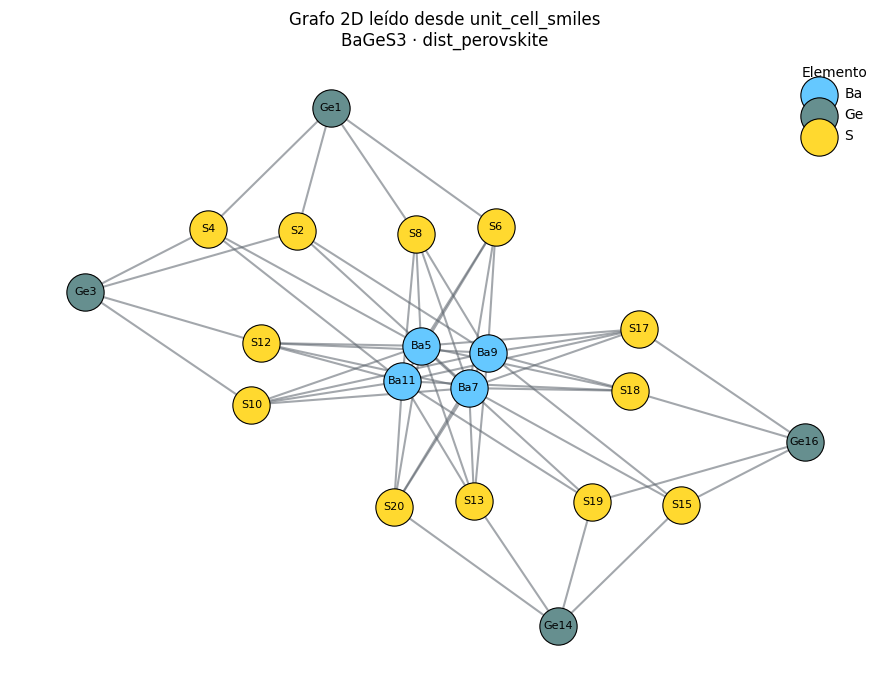

20 átomos y 56 enlaces reconstruidos desde el SMILES
[Ge]123S45[Ge]67S81[Ba]19%10%11%12%13%14%15[S]%16%172[Ba]2%18%19%20%21%22%234[S]431[Ba]13%24%25%26%275%16[S]692[Ba]25698%174([S]7%10%181)[S]%11%20%24[Ge]1(S%193[Ge]([S]%13%22%265)([S]%14%23%276)S%1591)[S]%12%21%252


In [7]:
import networkx as nx

sample_row = static.sort_values(['canonical_reduced_formula', 'prototype']).iloc[0]
sample_smiles = sample_row['unit_cell_smiles']
parsed = subprocess.run(
    [str(PYTHON), str(SCRIPTS / 'smiles_to_graph.py'), '--smiles', sample_smiles],
    cwd=REPO_ROOT, text=True, capture_output=True, check=True,
)
smiles_graph = json.loads(parsed.stdout)

graph = nx.Graph()
for atom in smiles_graph['atoms']:
    graph.add_node(atom['index'], element=atom['element'])
for bond in smiles_graph['bonds']:
    graph.add_edge(bond['source'], bond['target'])

element_colors = {'Ba': '#65c8ff', 'Ge': '#668f8f', 'S': '#ffd92f'}
position = nx.spring_layout(
    graph, seed=42, k=1.15 / len(graph) ** 0.5, iterations=250
)
fig, ax = plt.subplots(figsize=(9, 7))
nx.draw_networkx_edges(graph, position, ax=ax, width=1.5, alpha=0.55, edge_color='#586069')
for element in sorted({data['element'] for _, data in graph.nodes(data=True)}):
    nodes = [node for node, data in graph.nodes(data=True) if data['element'] == element]
    nx.draw_networkx_nodes(
        graph, position, nodelist=nodes, node_color=element_colors.get(element, '#cccccc'),
        node_size=720, edgecolors='black', linewidths=0.8, label=element, ax=ax,
    )
labels = {node: f"{data['element']}{node}" for node, data in graph.nodes(data=True)}
nx.draw_networkx_labels(graph, position, labels=labels, font_size=8, ax=ax)
ax.set_title(
    f"Grafo 2D leído desde unit_cell_smiles\n{sample_row['canonical_reduced_formula']} · {sample_row['prototype']}"
)
ax.legend(title='Elemento', frameon=False)
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"{len(smiles_graph['atoms'])} átomos y {len(smiles_graph['bonds'])} enlaces reconstruidos desde el SMILES")
print(sample_smiles)

### La misma muestra reconstruida desde CIF

Esta vista sí usa las coordenadas cartesianas y la red almacenadas en el CIF. Las líneas forman la celda; no representan enlaces inferidos.

**Vista previa del CIF generado para la muestra**

```cif
# generated using pymatgen
data_BaGeS3
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   7.71446998
_cell_length_b   8.15086033
_cell_length_c   7.98068614
_cell_angle_alpha   89.99070303
_cell_angle_beta   89.96658331
_cell_angle_gamma   89.96417105
_symmetry_Int_Tables_number   1
_chemical_formula_structural   BaGeS3
_chemical_formula_sum   'Ba4 Ge4 S12'
_cell_volume   501.82190136
_cell_formula_units_Z   4
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Ba  Ba0  1  0.03792158  0.98030405  0.24829540  1
  Ba  Ba1  1  0.53817515  0.48222817  0.74825154  1
...
```

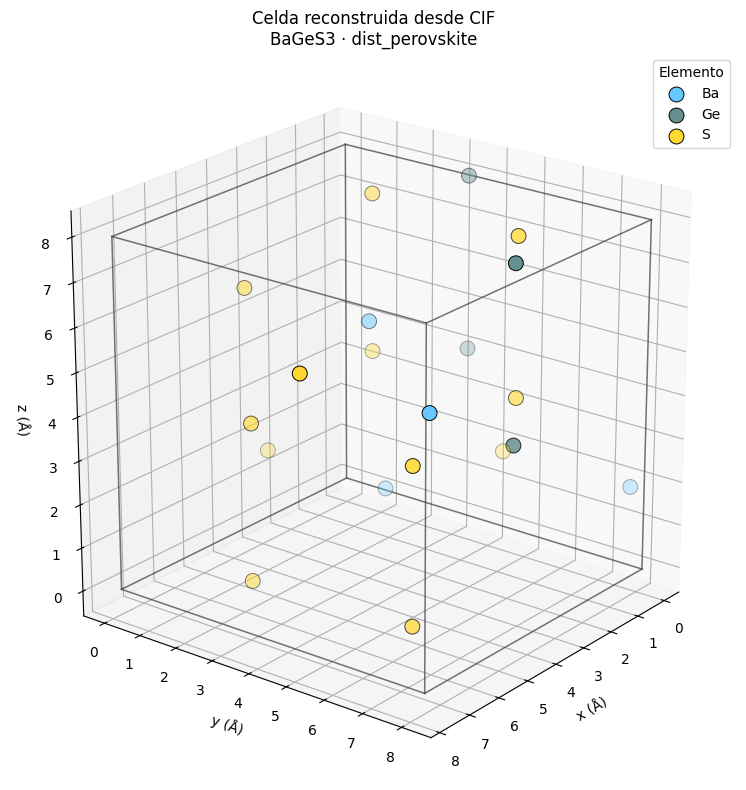

CIF re-leído: 20 sitios; volumen = 501.822 Å³


In [8]:
from itertools import product

import numpy as np
from IPython.display import Markdown, display
from pymatgen.core import Structure
from pymatgen.io.cif import CifWriter

source_records = json.loads((REPO_ROOT / 'data' / 'results_no_meta.json').read_text())
source_structure = Structure.from_dict(source_records[sample_row['record_id']]['structure'])
cif_text = str(CifWriter(source_structure, symprec=None))
structure_from_cif = Structure.from_str(cif_text, fmt='cif')
cif_preview = '\n'.join(cif_text.splitlines()[:28])
display(Markdown('**Vista previa del CIF generado para la muestra**\n\n```cif\n' + cif_preview + '\n...\n```'))

coordinates = structure_from_cif.cart_coords
lattice = structure_from_cif.lattice.matrix
corners_fractional = list(product([0, 1], repeat=3))
corners_cartesian = {corner: np.asarray(corner) @ lattice for corner in corners_fractional}

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')
for first in corners_fractional:
    for second in corners_fractional:
        if sum(a != b for a, b in zip(first, second)) == 1 and first < second:
            segment = np.vstack([corners_cartesian[first], corners_cartesian[second]])
            ax.plot(*segment.T, color='#444444', linewidth=1.1, alpha=0.75)

site_elements = np.array([site.specie.symbol for site in structure_from_cif])
for element in sorted(set(site_elements)):
    mask = site_elements == element
    ax.scatter(
        *coordinates[mask].T, s=115, color=element_colors.get(element, '#cccccc'),
        edgecolor='black', linewidth=0.7, depthshade=True, label=element,
    )
all_points = np.vstack([coordinates, *corners_cartesian.values()])
extent = np.maximum(np.ptp(all_points, axis=0), 1e-6)
ax.set_box_aspect(extent)
ax.set(xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)')
ax.set_title(
    f"Celda reconstruida desde CIF\n{sample_row['canonical_reduced_formula']} · {sample_row['prototype']}"
)
ax.view_init(elev=22, azim=38)
ax.legend(title='Elemento')
plt.tight_layout()
plt.show()
print(f"CIF re-leído: {len(structure_from_cif)} sitios; volumen = {structure_from_cif.volume:.3f} Å³")

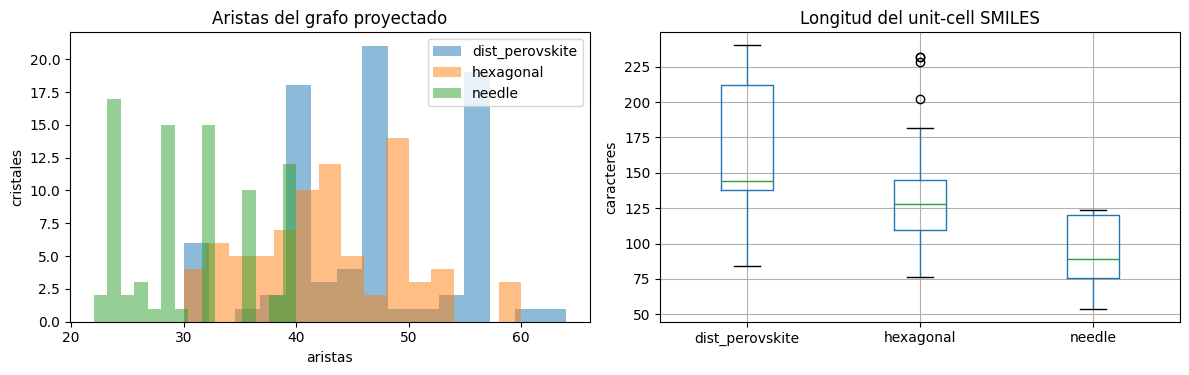

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for prototype, group in static.groupby('prototype'):
    axes[0].hist(group['quotient_edges'], bins=15, alpha=0.5, label=prototype)
axes[0].set(title='Aristas del grafo proyectado', xlabel='aristas', ylabel='cristales')
axes[0].legend()
static.assign(smiles_length=static['unit_cell_smiles'].str.len()).boxplot(
    column='smiles_length', by='prototype', ax=axes[1]
)
axes[1].set(title='Longitud del unit-cell SMILES', xlabel='', ylabel='caracteres')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Sanity check de invariancia

Para los tres prototipos de una fórmula comprobamos permutación de átomos, desplazamiento del origen y permutación cíclica de ejes. Una supercelda duplica los nodos, de modo que esta representación de celda completa no puede ser invariante a superceldas por construcción.

In [10]:
INVARIANCE_AUDIT = TABLE.with_name('invariance_audit.json')
run_script([SCRIPTS / 'audit_unit_cell_invariance.py'], tail=2600)
invariance = json.loads(INVARIANCE_AUDIT.read_text())
pd.DataFrame(invariance['results']).set_index('prototype')

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/audit_unit_cell_invariance.py


{
  "formula_tested": "Ba1Ge1S3",
  "transformations": {
    "atom_permutation": "reverse site order",
    "origin_shift_fractional": [
      0.137,
      0.271,
      0.389
    ],
    "axis_permutation": "(a,b,c) -> (b,c,a)",
    "supercell": "2x1x1; not encoded because the node count necessarily doubles"
  },
  "results": [
    {
      "record_id": "Ba1Ge1S3--Ba1Ge1S3_dist_perovskite--nm--gga-static",
      "prototype": "dist_perovskite",
      "original_sites": 20,
      "original_edges": 56,
      "atom_permutation_invariant": true,
      "origin_shift_invariant": true,
      "cyclic_axis_permutation_invariant": true,
      "supercell_sites": 40,
      "supercell_invariant_by_construction": false
    },
    {
      "record_id": "Ba1Ge1S3--Ba1Ge1S3_hexagonal--nm--gga-static",
      "prototype": "hexagonal",
      "original_sites": 20,
      "original_edges": 41,
      "atom_permutation_invariant": true,
      "origin_shift_invariant": true,
      "cyclic_axis_permutation_invariant":

,record_id,original_sites,original_edges,atom_permutation_invariant,origin_shift_invariant,cyclic_axis_permutation_invariant,supercell_sites,supercell_invariant_by_construction
prototype,,,,,,,,
dist_perovskite,Ba1Ge1S3--Ba1Ge1S3_dist_perovskite--nm--gga-st...,20,56,True,True,True,40,False
hexagonal,Ba1Ge1S3--Ba1Ge1S3_hexagonal--nm--gga-static,20,41,True,True,True,40,False
needle,Ba1Ge1S3--Ba1Ge1S3_needle--nm--gga-static,20,40,True,True,True,40,False


## 3. Extraer embeddings para los dos controles de celda

In [11]:
if RUN_EMBEDDINGS:
    for column in ['unit_cell_disconnected_smiles', 'unit_cell_smiles']:
        run_script([
            SCRIPTS / 'extract_frozen_embeddings.py',
            '--input', TABLE, '--smiles-column', column,
            '--representation-name', column, '--device', DEVICE,
        ], tail=3200)

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/extract_frozen_embeddings.py --input /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv --smiles-column unit_cell_disconnected_smiles --representation-name unit_cell_disconnected_smiles --device auto


rid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv",
  "smiles_column": "unit_cell_disconnected_smiles",
  "representation_name": "unit_cell_disconnected_smiles",
  "pooling": "last_hidden_state_mean_without_special_tokens",
  "embedding_shape": [
    480,
    768
  ],
  "records": 480,
  "unique_inputs": 80,
  "token_count_min": 85,
  "token_count_max": 89,
  "untruncated_token_count_min": 85,
  "untruncated_token_count_max": 89,
  "model_max_length_used": 512,
  "unique_inputs_truncated": 0,
  "unknown_token_total": 0,
  "unique_inputs_with_unknown_tokens": 0,
  "device": "mps"
}
Loading molformer: ibm-research/MoLFormer-XL-both-10pct@361063d0ad524ef77cf39b08469f6be770dc550f
{
  "model_alias": "molformer",
  "repo_id": "ibm-research/MoLFormer-XL-both-10pct",
  "revision": "361063d0ad524ef77cf39b08469f6be770dc550f",
  "input_table": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-t

865a20",
  "input_table": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv",
  "smiles_column": "unit_cell_smiles",
  "representation_name": "unit_cell_smiles",
  "pooling": "last_hidden_state_mean_without_special_tokens",
  "embedding_shape": [
    480,
    768
  ],
  "records": 480,
  "unique_inputs": 240,
  "token_count_min": 54,
  "token_count_max": 219,
  "untruncated_token_count_min": 54,
  "untruncated_token_count_max": 219,
  "model_max_length_used": 512,
  "unique_inputs_truncated": 0,
  "unknown_token_total": 0,
  "unique_inputs_with_unknown_tokens": 0,
  "device": "mps"
}
Loading molformer: ibm-research/MoLFormer-XL-both-10pct@361063d0ad524ef77cf39b08469f6be770dc550f
{
  "model_alias": "molformer",
  "repo_id": "ibm-research/MoLFormer-XL-both-10pct",
  "revision": "361063d0ad524ef77cf39b08469f6be770dc550f",
  "input_table": "/Users/cristellemadrid/Desktop/Transformers/transformers

In [12]:
audits = []
for path in sorted((ARTIFACTS / 'embeddings').glob('*.audit.json')):
    item = json.loads(path.read_text())
    if item.get('representation_name') in {
        'composition_smiles', 'unit_cell_disconnected_smiles', 'unit_cell_smiles'
    }:
        audits.append({
            'modelo': item['model_alias'], 'representación': item['representation_name'],
            'inputs únicos': item['unique_inputs'],
            'tokens min': item['untruncated_token_count_min'],
            'tokens max': item['untruncated_token_count_max'],
            'truncados': item['unique_inputs_truncated'],
            'con UNK': item['unique_inputs_with_unknown_tokens'],
        })
pd.DataFrame(audits).sort_values(['modelo', 'representación']).reset_index(drop=True)

,modelo,representación,inputs únicos,tokens min,tokens max,truncados,con UNK
0,chemberta,composition_smiles,80,22,23,0,0
1,chemberta,unit_cell_disconnected_smiles,80,85,89,0,0
2,chemberta,unit_cell_smiles,240,54,219,0,0
3,molformer,composition_smiles,80,11,11,0,0
4,molformer,unit_cell_disconnected_smiles,80,41,41,0,0
5,molformer,unit_cell_smiles,240,32,118,0,0


## 4. Evaluar con los mismos folds agrupados por fórmula

In [13]:
representations = {
    'Unit cell disconnected': 'unit_cell_disconnected_smiles',
    'Unit-cell graph': 'unit_cell_smiles',
}
targets = {'Energy': 'energy_per_atom', 'Band gap': 'bandgap'}

if RUN_EVALUATION:
    for label, representation in representations.items():
        for target_label, target in targets.items():
            output = ARTIFACTS / 'evaluation' / f'{representation}_{target}.json'
            run_script([
                SCRIPTS / 'evaluate_frozen_transfer.py',
                '--table', TABLE,
                '--embeddings',
                ARTIFACTS / 'embeddings' / f'chemberta_{representation}.npz',
                ARTIFACTS / 'embeddings' / f'molformer_{representation}.npz',
                '--representation-column', representation,
                '--target', target, '--calculation', 'gga-static',
                '--output', output,
            ], tail=900)

$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/python /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/scripts/evaluate_frozen_transfer.py --table /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/unit_cell_SMILES/unit_cell_smiles.csv --embeddings /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/artifacts/embeddings/chemberta_unit_cell_disconnected_smiles.npz /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/artifacts/embeddings/molformer_unit_cell_disconnected_smiles.npz --representation-column unit_cell_disconnected_smiles --target energy_per_atom --calculation gga-static --output /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/artifacts/evaluation/unit_cell_disconnected_smiles_energy_per_atom.json


      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.05370259281081984,
      "rmse": 0.07340043275364172,
      "r2": 0.9923620271097239
    },
    "folds": [
      {
        "fold": 0,
        "mae": 0.06623278535253159,
        "rmse": 0.08059415957688336,
        "r2": 0.9902520030693464
      },
      {
        "fold": 1,
        "mae": 0.05902024171962395,
        "rmse": 0.0698064231032451,
        "r2": 0.9906934418076935
      },
      {
        "fold": 2,
        "mae": 0.04987563506329096,
        "rmse": 0.06936738833453303,
        "r2": 0.9913368663034787
      },
      {
        "fold": 3,
        "mae": 0.03998066032641454,
        "rmse": 0.054930503614884524,
        "r2": 0.9952774402303685
      },
      {
        "fold": 4,
        "mae": 0.05340364159223817,
        "rmse": 0.08798049548619986,
        "r2": 0.9916818937754595
      }
    ]
  }
}
$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/py

Ti",
      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.42011919050658586,
      "rmse": 0.5350272376210486,
      "r2": 0.43102486511098903
    },
    "folds": [
      {
        "fold": 0,
        "mae": 0.5766426294242201,
        "rmse": 0.684601711814998,
        "r2": 0.2751070758127562
      },
      {
        "fold": 1,
        "mae": 0.357859988383696,
        "rmse": 0.44880922379684407,
        "r2": 0.45108152969983895
      },
      {
        "fold": 2,
        "mae": 0.45484802082443937,
        "rmse": 0.6070204194990315,
        "r2": 0.43007611364056797
      },
      {
        "fold": 3,
        "mae": 0.3509815721229755,
        "rmse": 0.4188850564407772,
        "r2": 0.6212065438164711
      },
      {
        "fold": 4,
        "mae": 0.36026374177759823,
        "rmse": 0.46607190603889176,
        "r2": 0.29319426273431803
      }
    ]
  }
}
$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/py

      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.05370259281081984,
      "rmse": 0.07340043275364172,
      "r2": 0.9923620271097239
    },
    "folds": [
      {
        "fold": 0,
        "mae": 0.06623278535253159,
        "rmse": 0.08059415957688336,
        "r2": 0.9902520030693464
      },
      {
        "fold": 1,
        "mae": 0.05902024171962395,
        "rmse": 0.0698064231032451,
        "r2": 0.9906934418076935
      },
      {
        "fold": 2,
        "mae": 0.04987563506329096,
        "rmse": 0.06936738833453303,
        "r2": 0.9913368663034787
      },
      {
        "fold": 3,
        "mae": 0.03998066032641454,
        "rmse": 0.054930503614884524,
        "r2": 0.9952774402303685
      },
      {
        "fold": 4,
        "mae": 0.05340364159223817,
        "rmse": 0.08798049548619986,
        "r2": 0.9916818937754595
      }
    ]
  }
}
$ /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/.venv/bin/py

Ti",
      "V",
      "Zn",
      "Zr"
    ],
    "overall": {
      "mae": 0.42011919050658586,
      "rmse": 0.5350272376210486,
      "r2": 0.43102486511098903
    },
    "folds": [
      {
        "fold": 0,
        "mae": 0.5766426294242201,
        "rmse": 0.684601711814998,
        "r2": 0.2751070758127562
      },
      {
        "fold": 1,
        "mae": 0.357859988383696,
        "rmse": 0.44880922379684407,
        "r2": 0.45108152969983895
      },
      {
        "fold": 2,
        "mae": 0.45484802082443937,
        "rmse": 0.6070204194990315,
        "r2": 0.43007611364056797
      },
      {
        "fold": 3,
        "mae": 0.3509815721229755,
        "rmse": 0.4188850564407772,
        "r2": 0.6212065438164711
      },
      {
        "fold": 4,
        "mae": 0.36026374177759823,
        "rmse": 0.46607190603889176,
        "r2": 0.29319426273431803
      }
    ]
  }
}


## 5. ¿Mejora frente a composition-SMILES?

MAE menor es mejor. `Δ MAE` negativo significa mejora respecto al composition-SMILES del mismo modelo y target.

In [14]:
result_paths = {
    ('Reduced composition', 'Energy'): ARTIFACTS / 'evaluation' / 'frozen_transfer.json',
    ('Reduced composition', 'Band gap'): ARTIFACTS / 'evaluation' / 'frozen_transfer_bandgap.json',
}
for label, representation in representations.items():
    for target_label, target in targets.items():
        result_paths[(label, target_label)] = (
            ARTIFACTS / 'evaluation' / f'{representation}_{target}.json'
        )

rows = []
collision_rows = []
for (representation, target), path in result_paths.items():
    result = json.loads(path.read_text())
    for model, values in result['models'].items():
        rows.append({
            'representación': representation, 'target': target, 'modelo': model,
            **values['overall'],
        })
    collision_rows.append({
        'representación': representation, 'target': target,
        **result['representation_collision_floor'],
    })
comparison = pd.DataFrame(rows)
baseline_mae = (comparison[comparison['representación'] == 'Reduced composition']
                .set_index(['target', 'modelo'])['mae'])
comparison['Δ MAE vs composition'] = comparison.apply(
    lambda row: row['mae'] - baseline_mae.loc[(row['target'], row['modelo'])], axis=1
)
comparison.sort_values(['target', 'modelo', 'representación']).round(4)

,representación,target,modelo,mae,rmse,r2,Δ MAE vs composition
2,Reduced composition,Band gap,chemberta,0.5087,0.6559,0.1449,0.0000
6,Unit cell disconnected,Band gap,chemberta,0.4860,0.6448,0.1736,-0.0227
10,Unit-cell graph,Band gap,chemberta,0.5783,0.7943,-0.2541,0.0696
3,Reduced composition,Band gap,molformer,0.6725,0.8446,-0.4178,0.0000
7,Unit cell disconnected,Band gap,molformer,0.5200,0.7018,0.0210,-0.1525
11,Unit-cell graph,Band gap,molformer,0.7737,1.0758,-1.3003,0.1012
0,Reduced composition,Energy,chemberta,0.1508,0.2669,0.8990,0.0000
4,Unit cell disconnected,Energy,chemberta,0.2325,0.3489,0.8274,0.0817
8,Unit-cell graph,Energy,chemberta,0.5646,0.7822,0.1325,0.4138
1,Reduced composition,Energy,molformer,0.4509,0.5755,0.5304,0.0000


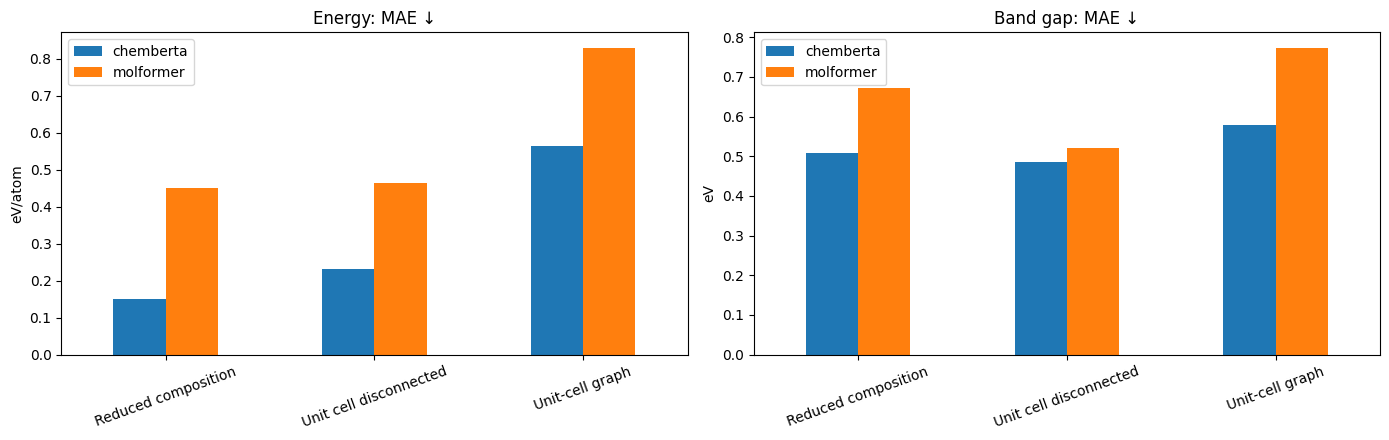

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
for axis, target in zip(axes, ['Energy', 'Band gap']):
    subset = comparison[comparison['target'] == target]
    subset.pivot(index='representación', columns='modelo', values='mae').plot.bar(ax=axis)
    axis.set(title=f'{target}: MAE ↓', xlabel='', ylabel='eV/atom' if target == 'Energy' else 'eV')
    axis.tick_params(axis='x', rotation=20)
    axis.legend(title='')
plt.tight_layout()
plt.show()

## Colisiones de representación

El error de colisión es descriptivo y usa las etiquetas conocidas; no es un resultado predictivo. Debe caer a cero cuando cada prototipo tiene un string distinto.

In [16]:
pd.DataFrame(collision_rows)[
    ['representación', 'target', 'unique_representation_strings', 'mae', 'rmse', 'r2']
].sort_values(['target', 'representación']).round(4)

,representación,target,unique_representation_strings,mae,rmse,r2
1,Reduced composition,Band gap,80,0.2651,0.3922,0.6943
3,Unit cell disconnected,Band gap,80,0.2651,0.3922,0.6943
5,Unit-cell graph,Band gap,240,0.0000,0.0000,1.0000
0,Reduced composition,Energy,80,0.0350,0.0496,0.9965
2,Unit cell disconnected,Energy,80,0.0350,0.0496,0.9965
4,Unit-cell graph,Energy,240,0.0000,0.0000,1.0000


## Interpretación

Distinguir los polimorfos elimina la ambigüedad `mismo X → diferentes y`, pero no garantiza mejor generalización. Si el unit-cell graph empeora, las hipótesis principales son: conectividad `CrystalNN` demasiado ruidosa para estos modelos moleculares, pérdida de etiquetas periódicas/multiplicidad, strings muy alejados de la distribución de pretraining, y un regresor/hiperparámetro todavía no optimizado. El resultado debe reportarse como evidencia experimental, no corregirse buscando sólo una configuración favorable.